# Polynomial Regression 

Linear Regression finds the correlation between the dependent variable ( or target variable ) and independent variables ( or features ). In short, it is a linear model to fit the data linearly. But it fails to fit and catch the pattern in non-linear data. 

Let’s first apply Linear Regression on non-linear data to understand the need for Polynomial Regression. The Linear Regression model used in this article is imported from sklearn.

In [25]:
# Importing libraries
 
import numpy as np

import math
 
import pandas as pd
 
import matplotlib.pyplot as plt
 
from sklearn.linear_model import LinearRegression

X (First 5 values): [[-1.1374153 ]
 [-0.98608091]
 [-0.05734315]
 [ 0.04116933]
 [-0.83949966]]
Y (First 5 values): [[7.20225097]
 [7.24159138]
 [3.11186812]
 [2.29898311]
 [6.31369299]]


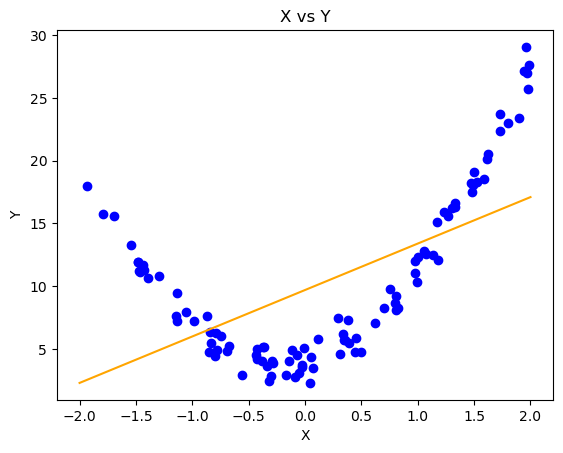

In [49]:
# Create dataset
 
# Generate 100 random values for X in the range [-2, 2)
X = 4 * np.random.rand(100, 1) - 2  
print("X (First 5 values):", X[:5])  # Display first 5 values of X for reference

# Generate Y values using a quadratic function with some noise
# The true equation: Y = 4 + 2X + 5X² + random noise
Y = 4 + 2 * X + 5 * X**2 + np.random.randn(100, 1)  
print("Y (First 5 values):", Y[:5])  # Display first 5 values of Y for reference

# Model training
 
model = LinearRegression()

model.fit( X, Y )
 
# Prediction

# Generate 100 evenly spaced values in the range [-2, 2] for smooth plotting
X_vals = np.linspace(-2, 2, 100).reshape(-1, 1)
y_vals = model.predict( X_vals )
 
# Visualization 
 
plt.scatter( X, Y, color = 'blue' )
 
plt.plot( X_vals, y_vals, color = 'orange' )
 
plt.title( 'X vs Y' )
 
plt.xlabel( 'X' )
 
plt.ylabel( 'Y' )
 
plt.show()

X (First 5 values): [[-0.32176096]
 [-1.4482194 ]
 [-1.8881095 ]
 [ 1.19032919]
 [ 0.53962778]]
Y (First 5 values): [[ 3.20145474]
 [11.25383137]
 [17.7028199 ]
 [13.2068421 ]
 [ 6.94998187]]
X_poly (First 5 rows): [[-0.32176096  0.10353012]
 [-1.4482194   2.09733944]
 [-1.8881095   3.56495749]
 [ 1.19032919  1.41688359]
 [ 0.53962778  0.29119814]]
X_vals_poly (First 5 rows): [[-2.          4.        ]
 [-1.95959596  3.84001632]
 [-1.91919192  3.68329762]
 [-1.87878788  3.52984389]
 [-1.83838384  3.37965514]]


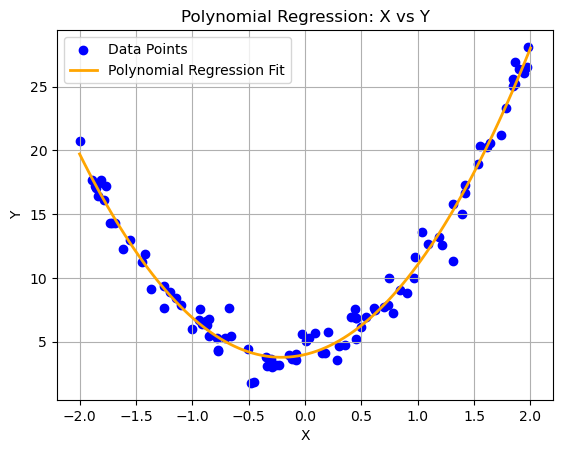

In [45]:
import numpy as np  # Importing NumPy for numerical operations
import matplotlib.pyplot as plt  # Importing Matplotlib for data visualization
from sklearn.preprocessing import PolynomialFeatures  # Importing PolynomialFeatures for polynomial transformation
from sklearn.linear_model import LinearRegression  # Importing LinearRegression model from scikit-learn

# ------------------------- DATA GENERATION -------------------------

# Generate 100 random values for X in the range [-2, 2)
X = 4 * np.random.rand(100, 1) - 2  
print("X (First 5 values):", X[:5])  # Display first 5 values of X for reference

# Generate Y values using a quadratic function with some noise
# The true equation: Y = 4 + 2X + 5X² + random noise
Y = 4 + 2 * X + 5 * X**2 + np.random.randn(100, 1)  
print("Y (First 5 values):", Y[:5])  # Display first 5 values of Y for reference

# ------------------------- POLYNOMIAL FEATURE TRANSFORMATION -------------------------

# Create polynomial features of degree 2 (i.e., include X² term)
poly_features = PolynomialFeatures(degree=2, include_bias=False)

# Transform X into a new feature matrix that includes X and X²
X_poly = poly_features.fit_transform(X)
print("X_poly (First 5 rows):", X_poly[:5])  # Display first 5 transformed values

# ------------------------- MODEL TRAINING -------------------------

# Create a Linear Regression model
model = LinearRegression()

# Train the model using the transformed polynomial features
model.fit(X_poly, Y)

# ------------------------- PREDICTION FOR VISUALIZATION -------------------------

# Generate 100 evenly spaced values in the range [-2, 2] for smooth plotting
X_vals = np.linspace(-2, 2, 100).reshape(-1, 1)

# Transform the new X values to include polynomial features (X and X²)
X_vals_poly = poly_features.transform(X_vals)
print("X_vals_poly (First 5 rows):", X_vals_poly[:5])  # Display first 5 transformed values

# Predict Y values using the trained model
y_vals = model.predict(X_vals_poly)

# ------------------------- VISUALIZATION -------------------------

# Scatter plot of original data points
plt.scatter(X, Y, color='blue', label="Data Points")

# Plot the polynomial regression curve
plt.plot(X_vals, y_vals, color='orange', linewidth=2, label="Polynomial Regression Fit")

# Add title and labels
plt.title('Polynomial Regression: X vs Y')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()  # Add legend to differentiate between actual points and model prediction
plt.grid(True)  # Add a grid for better readability

# Display the plot
plt.show()
